# PLS Regression — otimização de hiperparâmetros

**Etapa:** seleção usando somente treino e validação

A busca compara de 1 a 12 componentes, com padronização refeita dentro de cada janela de treino.

**Entrada:** protocolo, base modelável e origens de validação  
**Resultado principal:** configuração vencedora com MAE de validação 2.9701


## 1. Importações, caminhos e funções

In [ ]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [1]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. Funções de ajuste do PLS Regression

In [ ]:
from itertools import product
from sklearn.ensemble import RandomForestRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def ml_predict(df, origin, features, model, params):
    train = df.iloc[:origin]; test = df.iloc[[origin]]
    X_train, y_train = train[features], train.TARGET
    X_test = test[features]
    if model == "PLS_Regression":
        scaler = StandardScaler().fit(X_train)
        estimator = PLSRegression(n_components=params["n_components"], scale=False)
        estimator.fit(scaler.transform(X_train), y_train)
        pred = float(estimator.predict(scaler.transform(X_test)).ravel()[0])
    else:
        estimator = RandomForestRegressor(random_state=SEED, n_jobs=-1, **params).fit(X_train, y_train)
        pred = float(estimator.predict(X_test)[0])
    return pred

def ts_predict(df, origin, model, params, exog):
    y = df.GOLD_PRICE.iloc[:origin+1]
    if model == "SARIMAX":
        history_exog = df[exog].iloc[: origin + 1]
        future_exog = df[exog].iloc[[origin]].copy()
        target_date = df["TARGET_DATE"].iloc[origin]
        target_day_of_week = target_date.dayofweek
        target_month = target_date.month
        future_exog.loc[:, "DOW_SIN"] = np.sin(2 * np.pi * target_day_of_week / 7)
        future_exog.loc[:, "DOW_COS"] = np.cos(2 * np.pi * target_day_of_week / 7)
        future_exog.loc[:, "MONTH_SIN"] = np.sin(2 * np.pi * target_month / 12)
        future_exog.loc[:, "MONTH_COS"] = np.cos(2 * np.pi * target_month / 12)
        fitted = SARIMAX(y, exog=history_exog, order=tuple(params["order"]), seasonal_order=tuple(params["seasonal_order"]), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=100)
        return float(fitted.get_forecast(steps=1, exog=future_exog).predicted_mean.iloc[0])
    fitted = ExponentialSmoothing(y, trend=params["trend"], damped_trend=params["damped_trend"], seasonal=params["seasonal"], seasonal_periods=params["seasonal_periods"], initialization_method="estimated").fit(optimized=True)
    return float(fitted.forecast(1).iloc[0])



In [2]:
def predict_one(df, origin, model, params, protocol):
    if model in {"Random_Forest", "PLS_Regression"}: return ml_predict(df, origin, protocol["decisions"]["features"], model, params)
    return ts_predict(df, origin, model, params, protocol["sarimax_exog"])

def evaluate(df, ids, model, params, protocol):
    started=time.perf_counter(); records=[]
    for origin in ids:
        assert (df["TARGET_DATE"].iloc[:origin] <= df["DATE"].iloc[origin]).all()
        origin_started = time.perf_counter()
        prediction = predict_one(df, origin, model, params, protocol)
        origin_elapsed = time.perf_counter() - origin_started
        actual = float(df.TARGET.iloc[origin])
        records.append({"dataset":"gold", "model":model, "forecast_origin":df.DATE.iloc[origin].date().isoformat(), "target_date":df.TARGET_DATE.iloc[origin].date().isoformat(), "horizon":1, "y_true":actual, "y_pred":prediction, "residual":actual-prediction, "elapsed_seconds":origin_elapsed})
    output=pd.DataFrame(records); assert np.isfinite(output[["y_true","y_pred","residual"]]).all().all(); assert np.allclose(output.residual, output.y_true-output.y_pred)
    return output, float(mean_absolute_error(output.y_true, output.y_pred)), time.perf_counter()-started


## 3. Busca original de hiperparâmetros

### Espaço de busca

A tabela resume exatamente os candidatos definidos antes do teste final. O critério principal é o MAE walk-forward de validação.

In [ ]:
# Componentes avaliados pelo PLS
pls_space = pd.DataFrame(
    {
        "n_components": range(1, 13),
        "padronização": ["StandardScaler por janela"] * 12,
        "critério": ["MAE walk-forward de validação"] * 12,
    }
)
display(pls_space)

n_components,padronização,critério
1,StandardScaler por janela,MAE walk-forward de validação
2,StandardScaler por janela,MAE walk-forward de validação
3,StandardScaler por janela,MAE walk-forward de validação
4,StandardScaler por janela,MAE walk-forward de validação
5,StandardScaler por janela,MAE walk-forward de validação
6,StandardScaler por janela,MAE walk-forward de validação
7,StandardScaler por janela,MAE walk-forward de validação
8,StandardScaler por janela,MAE walk-forward de validação
9,StandardScaler por janela,MAE walk-forward de validação
10,StandardScaler por janela,MAE walk-forward de validação


> **Execução pesada**
>
> Esta célula produziu originalmente os resultados congelados. Ela é mantida para documentar o processo e não deve ser reexecutada apenas para visualizar o notebook.

In [ ]:
MODEL="PLS_Regression"
RUN_TUNING = True
if not RUN_TUNING:
    raise RuntimeError("DECISÃO NECESSÁRIA: confirme a execução pesada e altere RUN_TUNING para True.")
df=load_data(); protocol=load_protocol(require_data_decisions=True)
features = protocol["decisions"]["features"]
max_components = min(12, len(features), protocol["splits"]["train_end"] - 1)
candidates = [{"n_components": n} for n in range(1, max_components + 1)]
assert features == protocol["decisions"]["features"]
rows = []
candidate_outputs = {}
for params in candidates:
    try:
        predictions, mae, elapsed=evaluate(df, origins(protocol,"validation"), MODEL, params, protocol)
        key = json.dumps(params, sort_keys=True)
        candidate_outputs[key] = predictions
        rows.append({"model":MODEL,"parameters":key,"validation_mae":mae,"mae_3":round(mae,3),"complexity":params["n_components"],"mean_seconds_per_origin":predictions.elapsed_seconds.mean(),"elapsed_seconds":elapsed,"status":"ok"})
    except Exception as exc: rows.append({"model":MODEL,"parameters":json.dumps(params),"validation_mae":np.nan,"elapsed_seconds":np.nan,"status":f"failed: {type(exc).__name__}"})
ranking=pd.DataFrame(rows).sort_values(["mae_3","complexity","mean_seconds_per_origin"], na_position="last"); display(ranking)
ranking.to_csv(OUT / f"tuning_candidates_{MODEL}.csv", index=False)
winner = json.loads(ranking.iloc[0]["parameters"])
candidate_outputs[json.dumps(winner, sort_keys=True)].to_csv(OUT / f"validation_predictions_{MODEL}.csv", index=False)
print("Tuning concluído. Revise o ranking antes de executar o bloco de aceite.")

## 4. Parâmetros vencedores congelados

In [ ]:
MODEL = "PLS_Regression"
ACCEPTED_PARAMS = {"n_components": 11}
protocol = load_protocol(require_data_decisions=True)
ranking = pd.read_csv(OUT / f"tuning_candidates_{MODEL}.csv")
winner = json.loads(ranking.iloc[0]["parameters"])
display(ranking.head())
if ACCEPTED_PARAMS is None:
    raise RuntimeError("DECISÃO NECESSÁRIA: revise o ranking e preencha ACCEPTED_PARAMS; o teste final continua bloqueado.")
if json.dumps(ACCEPTED_PARAMS, sort_keys=True) != json.dumps(winner, sort_keys=True):
    raise ValueError("ACCEPTED_PARAMS deve ser o vencedor do critério fixado antes do tuning.")
protocol["decisions"]["accepted_parameters"][MODEL] = ACCEPTED_PARAMS
save_protocol(protocol)
selected = ranking.iloc[0]
selected_record = pd.DataFrame([{"dataset": "gold", "model": MODEL, "parameters": json.dumps(ACCEPTED_PARAMS, sort_keys=True), "validation_mae": selected.validation_mae, "mean_seconds_per_origin": selected.mean_seconds_per_origin, "n_candidates": len(ranking), "selection_criterion": json.dumps(protocol["selection_criterion"], ensure_ascii=False)}])
hyperparameters_path = OUT / "hyperparameters.csv"
if hyperparameters_path.exists():
    previous = pd.read_csv(hyperparameters_path)
    selected_record = pd.concat([previous[previous.model != MODEL], selected_record], ignore_index=True)
selected_record.to_csv(hyperparameters_path, index=False)
print("Parâmetros aceitos e teste final liberado apenas para este modelo.")

## Resultado congelado

In [ ]:
# Leitura leve do ranking congelado — não executa tuning
ranking_congelado = pd.read_csv(OUT / "tuning_candidates_PLS_Regression.csv")
ranking_congelado = ranking_congelado.sort_values("validation_mae").head(5)
display(ranking_congelado[['parameters', 'validation_mae', 'mean_seconds_per_origin', 'status']])

parameters,validation_mae,mean_seconds_per_origin,status
"{""n_components"": 11}",2.970125,0.025383,ok
"{""n_components"": 12}",2.979423,0.037762,ok
"{""n_components"": 10}",3.173732,0.023376,ok
"{""n_components"": 9}",3.931741,0.023545,ok
"{""n_components"": 8}",3.963827,0.030090,ok


### Curva de validação

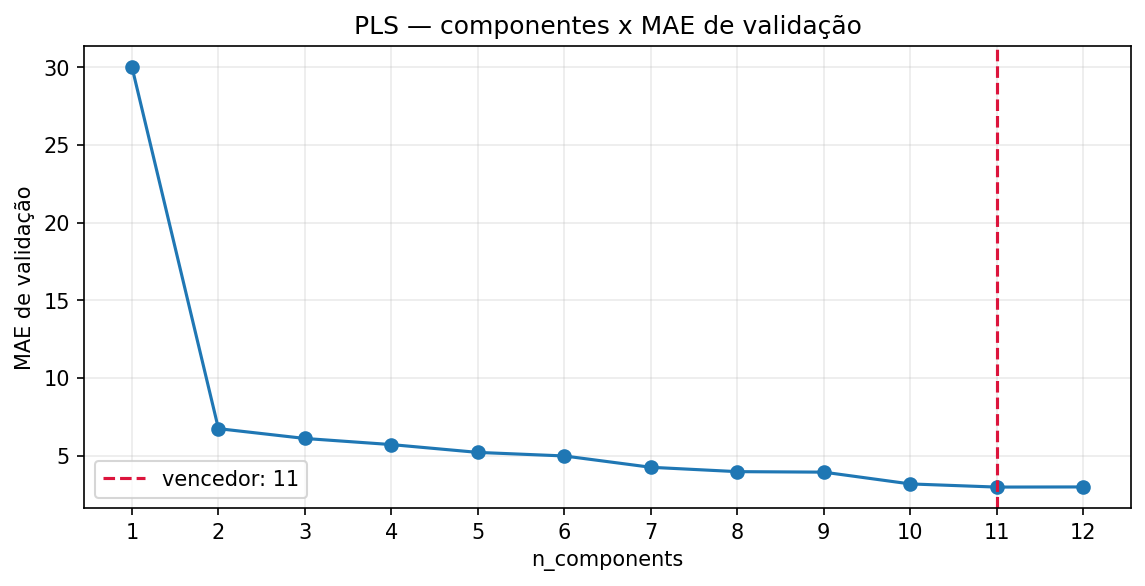

In [ ]:
# Curva de validação dos componentes
pls_tuning = pd.read_csv(OUT / "tuning_candidates_PLS_Regression.csv")
pls_tuning["n_components"] = pls_tuning["parameters"].map(json.loads).map(lambda value: value["n_components"])
pls_tuning = pls_tuning.sort_values("n_components")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pls_tuning["n_components"], pls_tuning["validation_mae"], marker="o")
ax.axvline(11, color="crimson", linestyle="--", label="vencedor: 11")
ax.set(title="PLS — componentes x MAE de validação", xlabel="n_components", ylabel="MAE de validação")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

O primeiro candidato é o vencedor congelado do PLS Regression. A tabela mostra somente os cinco melhores para facilitar a leitura.

## Interpretação

O vencedor foi escolhido pelo menor MAE walk-forward de validação. O teste final não participou da seleção. O resultado está congelado e a busca não precisa ser reexecutada.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/tuning_candidates_PLS_Regression.csv`
- `outputs/hyperparameters.csv`
- `outputs/validation_predictions_PLS_Regression.csv`